In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

In [2]:
f = h5py.File("event_93970574.h5")
list(f.keys())

['positions', 'times', 'traces']

In [32]:
traces = f["traces"][:]
traces.shape

(14, 96, 2, 65536)

In [33]:
for i in range(14):
    store = []
    for j in range(96):
        if (traces[i,j,j%2]!=0).all():
            print(f"stn{i} ch{j} not 0")
        else:
            if (traces[i,j,(j+1)%2]==0).all():
                store.append(j)
    print(f"Empty channels for stn {i}:", store)

Empty channels for stn 0: [92, 93, 94, 95]
Empty channels for stn 1: [92, 93, 94, 95]
Empty channels for stn 2: [94, 95]
Empty channels for stn 3: [82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95]
Empty channels for stn 4: [94, 95]
Empty channels for stn 5: [82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95]
Empty channels for stn 6: [88, 89, 90, 91, 92, 93, 94, 95]
Empty channels for stn 7: [80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95]
Empty channels for stn 8: [86, 87, 88, 89, 90, 91, 92, 93, 94, 95]
Empty channels for stn 9: [90, 91, 92, 93, 94, 95]
Empty channels for stn 10: [92, 93, 94, 95]
Empty channels for stn 11: [86, 87, 88, 89, 90, 91, 92, 93, 94, 95]
Empty channels for stn 12: [76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95]
Empty channels for stn 13: [90, 91, 92, 93, 94, 95]


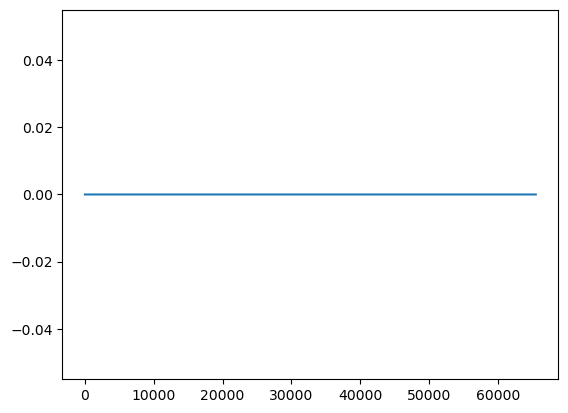

In [34]:
plt.plot(traces[13,94,0])
plt.show()

In [35]:
(traces[13,94,0]!=0).all()

np.False_

In [36]:
new = np.where(np.arange(96)%2==0, 1, 0)

In [44]:
reduced  = traces[:, np.arange(96), new, :]

In [45]:
reduced = reduced[:, :-2]

In [49]:
for i in range(14):
    store = []
    for j in range(94):
        if (reduced[i,j]==0).all():
            if (reduced[i,j]==0).all():
                store.append(j)
    print(f"Empty channels for stn {i}:", store)

Empty channels for stn 0: [92, 93]
Empty channels for stn 1: [92, 93]
Empty channels for stn 2: []
Empty channels for stn 3: [82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93]
Empty channels for stn 4: []
Empty channels for stn 5: [82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93]
Empty channels for stn 6: [88, 89, 90, 91, 92, 93]
Empty channels for stn 7: [80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93]
Empty channels for stn 8: [86, 87, 88, 89, 90, 91, 92, 93]
Empty channels for stn 9: [90, 91, 92, 93]
Empty channels for stn 10: [92, 93]
Empty channels for stn 11: [86, 87, 88, 89, 90, 91, 92, 93]
Empty channels for stn 12: [76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93]
Empty channels for stn 13: [90, 91, 92, 93]


In [51]:
np.unravel_index(np.argmax(reduced), reduced.shape)

(np.int64(2), np.int64(32), np.int64(33336))

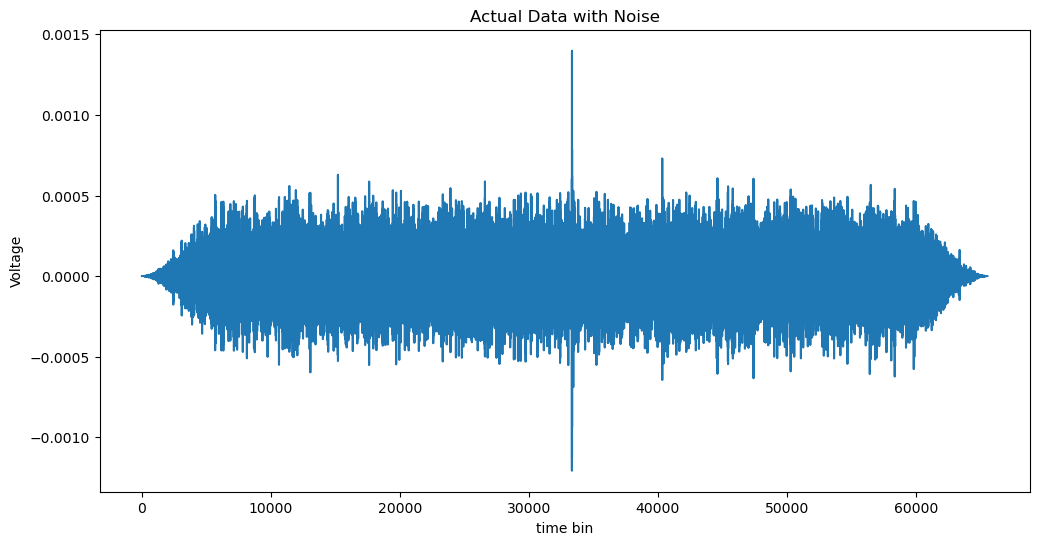

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(reduced[2, 32])
plt.xlabel("time bin")
plt.ylabel("Voltage")
plt.title("Actual Data with Noise")
plt.show()

In [55]:
np.argmax(reduced[2,32])+[-3000, 9000]

array([30336, 42336])

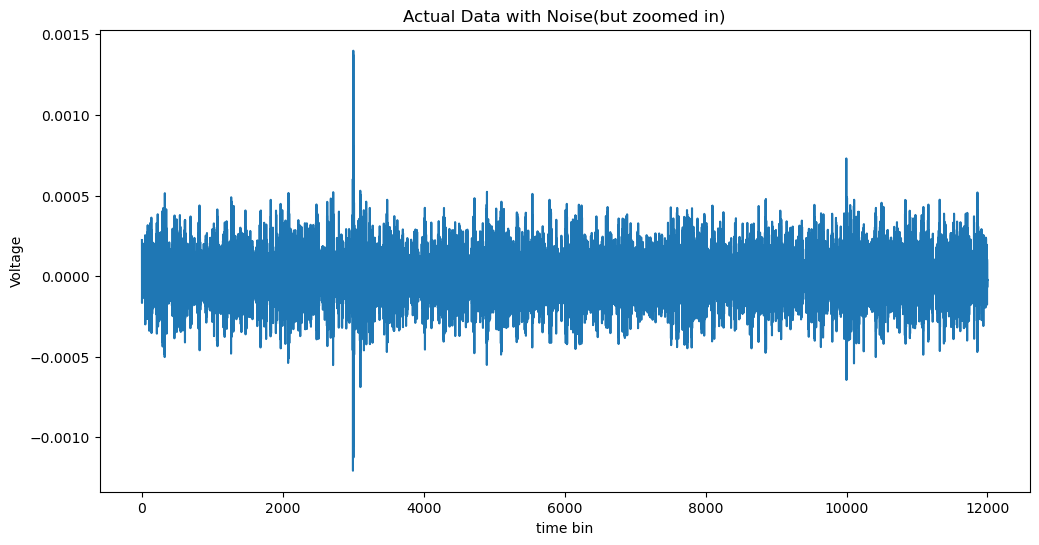

In [59]:
argmax = np.argmax(reduced[2,32])
plt.figure(figsize=(12,6))
plt.plot(reduced[2, 32][argmax-3000:argmax+9000])
plt.xlabel("time bin")
plt.ylabel("Voltage")
plt.title("Actual Data with Noise(but zoomed in)")
plt.show()